<a href="https://colab.research.google.com/github/gamzedrn/Softito-Egitim-Calismalari/blob/main/Salary-Decision-Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# GEREKLİ KÜTÜPHANELERİ İÇE AKTAR
import pandas as pd       # Veri manipülasyonu (tablo işlemleri)
import numpy as np        # Sayısal işlemler
import matplotlib.pyplot as plt  # Grafik çizmek için
import seaborn as sns      # Gelişmiş istatistik grafikleri
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree, export_text

## Veri Setini İnceleme

In [ ]:
# VERİYİ YÜKLE
df = pd.read_csv('/salary.csv')   # CSV → DataFrame nesnesine dönüştür

In [ ]:
# İLK BAKIŞ
print(f"Veri seti boyutu: {df.shape}")   # (satır, sütun) → (1164, 10)
print(df.head(3))

Veri seti boyutu: (1164, 10)
                      Time            Position     Level Experience  \
0  2023-01-22 18:49:36.202   Backend Developer       Mid    1-3 Yıl   
1  2023-01-22 18:49:38.280   Architect / Mimar  Tanımsız    4-6 Yıl   
2  2023-01-22 18:49:41.383  Frontend Developer    Junior    1-3 Yıl   

                                         Technology Location  \
0                                     Java / Spring  Türkiye   
1  React / NextJS, NodeJS, Javascript, React Native  Türkiye   
2                        React / NextJS, Javascript  Türkiye   

     Way_of_working Employees_number  Salary_type              Salary  
0  Yerinde / Ofiste          100-300  Türk Lirası  41.000 - 45.000 TL  
1            Remote            2000+  Türk Lirası  51.000 - 55.000 TL  
2            Remote          100-300  Türk Lirası  16.000 - 20.000 TL  


In [ ]:
# SÜTUN BİLGİLERİ
print(df.info())       # Veri tipleri, null sayıları, bellek kullanımı

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1164 entries, 0 to 1163
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Time              1164 non-null   object
 1   Position          1164 non-null   object
 2   Level             1164 non-null   object
 3   Experience        1164 non-null   object
 4   Technology        1164 non-null   object
 5   Location          1164 non-null   object
 6   Way_of_working    1164 non-null   object
 7   Employees_number  1164 non-null   object
 8   Salary_type       1164 non-null   object
 9   Salary            1164 non-null   object
dtypes: object(10)
memory usage: 91.1+ KB
None


In [ ]:
# İSTATİSTİKSEL ÖZET
print(df.describe())   # Sayısal sütunlar için min/max/mean/std


                           Time           Position   Level Experience  \
count                      1164               1164    1164       1164   
unique                     1164                110       4          5   
top     2023-01-26 16:28:23.767  Backend Developer  Junior    1-3 Yıl   
freq                          1                292     446        438   

                 Technology Location Way_of_working Employees_number  \
count                  1164     1164           1164             1164   
unique                  356        2              3                8   
top     C# / .NET Framework  Türkiye         Remote            10-30   
freq                    113     1033            600              217   

        Salary_type              Salary  
count          1164                1164  
unique           22                  20  
top     Türk Lirası  11.000 - 15.000 TL  
freq           1015                 210  


In [ ]:
# EKSİK VERİ KONTROLÜ
print(df.isnull().sum())   # Sütun başına kaç null değer var?

Time                0
Position            0
Level               0
Experience          0
Technology          0
Location            0
Way_of_working      0
Employees_number    0
Salary_type         0
Salary              0
dtype: int64


In [ ]:
# HEDEF DEĞİŞKENİN SINIF DAĞILIMI
print(df['Level'].value_counts())


Level
Junior      446
Mid         375
Senior      299
Tanımsız     44
Name: count, dtype: int64


In [ ]:
# TÜM KATEGORİK SÜTUNLAR
for col in df.columns:
    print(f"\n{col} ({df[col].nunique()} benzersiz değer):")
    print(df[col].value_counts().head(5))


Time (1164 benzersiz değer):
Time
2023-01-26 16:28:23.767    1
2023-01-22 18:49:36.202    1
2023-01-22 18:49:38.280    1
2023-01-22 18:49:41.383    1
2023-01-22 18:50:19.296    1
Name: count, dtype: int64

Position (110 benzersiz değer):
Position
Backend Developer      292
Fullstack Developer    274
Frontend Developer     198
Mobile Developer        99
Analist                 35
Name: count, dtype: int64

Level (4 benzersiz değer):
Level
Junior      446
Mid         375
Senior      299
Tanımsız     44
Name: count, dtype: int64

Experience (5 benzersiz değer):
Experience
1-3 Yıl    438
0-1 Yıl    268
4-6 Yıl    224
10+ Yıl    134
7-9 Yıl    100
Name: count, dtype: int64

Technology (356 benzersiz değer):
Technology
C# / .NET Framework           113
Java / Spring                  85
React / NextJS, Javascript     40
React / NextJS                 37
PHP / Laravel                  34
Name: count, dtype: int64

Location (2 benzersiz değer):
Location
Türkiye     1033
Yurtdışı     131
Name: 

## Veri Ön İşleme (Preprocessing)

In [ ]:
# ANLAMSIZ SÜTUNU KALDIR
# 'Time' → anketin doldurulma zamanı, tahmin için anlamsız
df = df.drop('Time', axis=1)
# axis=1: sütun sil (axis=0 satır siler)

In [ ]:
# TANIMSIZları ÇIKAR
# 'Tanımsız' etiketi gerçek bir Level değil; modeli yanıltır
df = df[df['Level'] != 'Tanımsız']
print(f"Tanımsız çıkarıldı: {df.shape}")

Tanımsız çıkarıldı: (1120, 9)


In [ ]:
# SALARY_TYPE TEMİZLİĞİ
# Sadece TL, Dolar, Euro tutuyoruz; geri kalanları 'Diğer' yapıyoruz
valid_currencies = ['Türk Lirası', 'Dolar', 'Euro', 'Sterlin']
df['Salary_type'] = df['Salary_type'].apply(
    lambda x: x if x in valid_currencies else 'Diğer'
)
# lambda: anonim (isimsiz) fonksiyon; her satır için çalıştırılır

In [ ]:
# 5. SALARY SÜTUNUNDAN ORTA DEĞER ÇIKAR
# "11.000 - 15.000 TL" → 13000.0 sayısına çevirelim
def parse_salary(s):
    s = s.replace('.', '').replace(' TL', '').replace('+', '')
    if '-' in s:
        parts = s.split('-')
        try:
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        except:
            return np.nan
    try:
        return float(s.strip())
    except:
        return np.nan

df['Salary_mid'] = df['Salary'].apply(parse_salary)
df = df.drop('Salary', axis=1)  # Orijinal metin sütununu sil
df = df.dropna(subset=['Salary_mid'])  # Çözülemeyenleri çıkar
print(f"Salary parse sonrası: {df.shape}")


Salary parse sonrası: (1120, 9)


In [ ]:
# LABEL ENCODING
# Kategorik sütunları sayıya çevir (model string anlamaz)
categorical_cols = ['Position', 'Experience', 'Technology',
                    'Location', 'Way_of_working',
                    'Employees_number', 'Salary_type']

le_dict = {}  # Her sütun için ayrı encoder saklıyoruz
for col in categorical_cols:
    le = LabelEncoder()            # Yeni encoder nesnesi oluştur
    df[col] = le.fit_transform(df[col])  # Öğren ve dönüştür
    le_dict[col] = le              # İleride decode etmek için sakla
    print(f"{col}: {list(le.classes_)[:5]}...")

Position: ['ABAP Developer', 'AI Research Engineer', 'Analist', 'Architect / Mimar', 'BT Müfettişi ']...
Experience: ['0-1 Yıl', '1-3 Yıl', '10+ Yıl', '4-6 Yıl', '7-9 Yıl']...
Technology: ['-', '3D MAX & AUTOCAD', 'ABAP', 'AWS, GCP, Azure, Linux, Kubernetes, Docker, CI/CD Tools', 'Abap']...
Location: ['Türkiye', 'Yurtdışı']...
Way_of_working: ['Hybrid', 'Remote', 'Yerinde / Ofiste']...
Employees_number: ['0-10', '10-30', '100-300', '1000-2000', '2000+']...
Salary_type: ['11500', '1250', '250 Dolar 4700tl ortalama', '25000', '3000']...


In [ ]:
# HEDEF DEĞİŞKENİ ENCODE ET
le_target = LabelEncoder()
df['Level_enc'] = le_target.fit_transform(df['Level'])
print(f"\nLevel encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")


Level encoding: {'Junior': np.int64(0), 'Mid': np.int64(1), 'Senior': np.int64(2)}


In [ ]:
# ÖZELLİKLER (X) VE HEDEF (y) AYIR
X = df.drop(['Level', 'Level_enc'], axis=1)
y = df['Level_enc']
print(f"\nÖzellik matrisi: {X.shape}")
print(f"Hedef vektör  : {y.shape}")
print(f"Özellikler: {list(X.columns)}")


Özellik matrisi: (1120, 8)
Hedef vektör  : (1120,)
Özellikler: ['Position', 'Experience', 'Technology', 'Location', 'Way_of_working', 'Employees_number', 'Salary_type', 'Salary_mid']


In [ ]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # %20 test, %80 eğitim
    random_state=42,     # Aynı bölünmeyi tekrar üretmek için sabit tohum
    stratify=y            # Sınıf oranlarını eğitim ve testte dengeli tut
)
print(f"\nEğitim seti : {X_train.shape}")
print(f"Test seti   : {X_test.shape}")
print(f"\nEğitim sınıf dağılımı:\n{y_train.value_counts()}")


Eğitim seti : (896, 8)
Test seti   : (224, 8)

Eğitim sınıf dağılımı:
Level_enc
0    357
1    300
2    239
Name: count, dtype: int64


## Decision Tree — Temel Kavramlar

Ağaç Kavramları
Root Node
Kök düğüm. Ağacın başlangıcı. Tüm veri burada; en iyi ayrım özelliği seçilir.

Internal Node
İç düğüm. Bir özelliğe göre test yapılır; iki veya daha fazla dala ayrılır.

Leaf Node
Yaprak. Artık bölünme olmaz; burada bir sınıf tahmini (Junior/Mid/Senior) verilir.

Branch
Dal. Düğümler arasındaki bağlantı; bir kural / koşulu temsil eder.

Max Depth
Ağacın maksimum derinliği. Sınırlanmazsa tüm eğitim setini ezberler (overfitting).

Overfitting
Aşırı öğrenme. Model eğitim setini ezberler; yeni veriye genelleme yapamaz.

Underfitting
Yetersiz öğrenme. Model çok basit; hem eğitim hem testte düşük başarı.



## Modeli Kur ve Eğit

In [ ]:
# MODELİ OLUŞTUR
model = DecisionTreeClassifier(
    criterion='gini',      # Bölünme kriteri: 'gini' veya 'entropy'
    max_depth=5,           # Max derinlik: overfitting önler
    min_samples_split=15, # Bir düğümü bölmek için minimum örnek sayısı
    min_samples_leaf=7,   # Yaprak düğümdeki minimum örnek sayısı
    random_state=42       # Tekrarlanabilirlik için sabit tohum
)
#
# PARAMETRE AÇIKLAMALARI:
# criterion='gini'     → Gini Impurity ile bölünme kriteri seç
# max_depth=5          → 5 kattan fazla derine inme (aşırı öğrenmeyi önler)
# min_samples_split=15 → Bir düğümde 15'ten az örnek varsa bölme
# min_samples_leaf=7   → Yaprak düğümde en az 7 örnek olsun
# random_state=42      → Sonuçların her çalıştırmada aynı olması için
#

print("Model parametreleri:")
print(model.get_params())

# MODELİ EĞİT
model.fit(X_train, y_train)
# fit(): Modeli eğitim verisiyle öğretir
# X_train: özellik matrisi (N x 8)
# y_train: hedef vektörü (N,)

print(f"\nModel eğitildi!")
print(f"Ağaç derinliği     : {model.get_depth()}")
print(f"Yaprak düğüm sayısı: {model.get_n_leaves()}")

# TAHMİN YAP
y_pred = model.predict(X_test)
# predict(): Modeli kullanarak test seti için sınıf tahminleri üretir
# Döndürür: [0, 1, 2, 0, 1, ...] (Junior=0, Mid=1, Senior=2)

y_pred_proba = model.predict_proba(X_test)
# predict_proba(): Her sınıf için olasılık değerlerini döndürür

print(f"\nİlk 5 tahmin  : {list(le_target.inverse_transform(y_pred[:5]))}")
print(f"İlk 5 gerçek  : {list(le_target.inverse_transform(y_test.values[:5]))}")
print(f"\nİlk 3 olasılık:\n{y_pred_proba[:3].round(2)}")

Model parametreleri:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 7, 'min_samples_split': 15, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Model eğitildi!
Ağaç derinliği     : 5
Yaprak düğüm sayısı: 24

İlk 5 tahmin  : ['Mid', 'Mid', 'Junior', 'Junior', 'Senior']
İlk 5 gerçek  : ['Senior', 'Mid', 'Junior', 'Junior', 'Senior']

İlk 3 olasılık:
[[0.02 0.82 0.16]
 [0.02 0.82 0.16]
 [1.   0.   0.  ]]


## Sonuçları Analiz Et

Precision = TP / (TP + FP)  ·  Recall = TP / (TP + FN)  ·  F1 = 2 × (P × R) / (P + R)


Doğruluk (Accuracy): 0.7411 = %74.1

Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Junior       0.85      0.82      0.83        89
         Mid       0.60      0.72      0.65        75
      Senior       0.81      0.65      0.72        60

    accuracy                           0.74       224
   macro avg       0.75      0.73      0.74       224
weighted avg       0.76      0.74      0.74       224


Eğitim Doğruluğu : 0.8114
Test  Doğruluğu  : 0.7411
⚠ Hafif overfitting olabilir


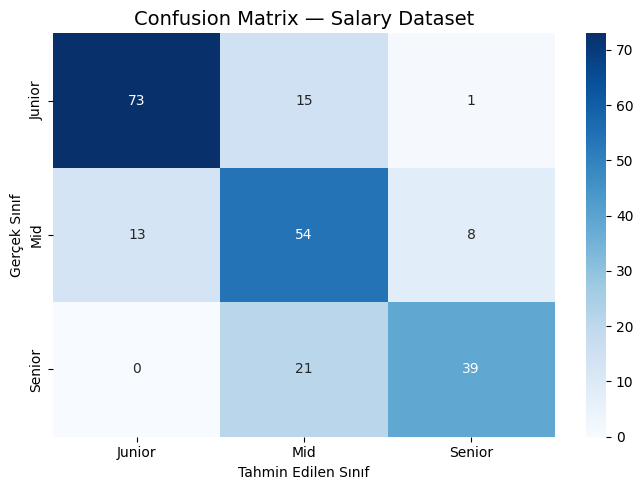


Özellik Önem Sıralaması:
            feature  importance
1        Experience    0.861754
7        Salary_mid    0.066454
2        Technology    0.030111
0          Position    0.020752
3          Location    0.012286
5  Employees_number    0.006605
6       Salary_type    0.002040
4    Way_of_working    0.000000


/tmp/ipykernel_8326/3861094305.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi, x='importance', y='feature', palette='viridis')


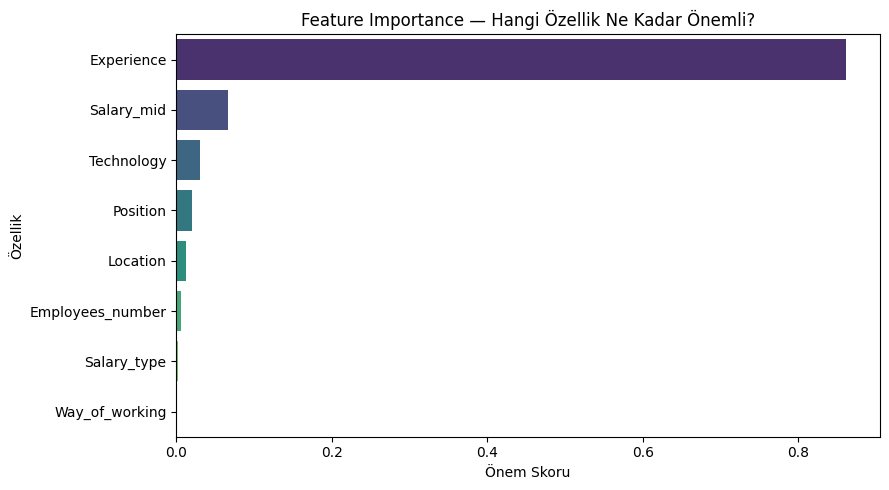

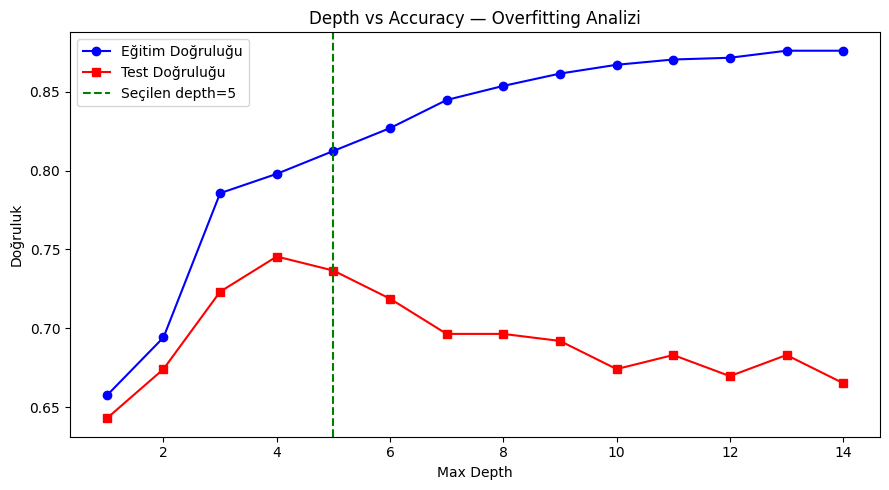

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class_names = le_target.classes_  # ['Junior', 'Mid', 'Senior']

# ── 1. ACCURACY ──────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print(f"Doğruluk (Accuracy): {acc:.4f} = %{acc*100:.1f}")

# ── 2. SINIFLANDIRMA RAPORU ───────────────────────────────────────────
print("\nSınıflandırma Raporu:")
print(classification_report(
    y_test, y_pred,
    target_names=class_names  # Sayı yerine isim göster
))
# classification_report: her sınıf için precision, recall, f1, support yazdırır

# ── 3. TRAIN vs TEST DOĞRULUĞU (Overfitting Kontrolü) ────────────────
train_acc = model.score(X_train, y_train)
test_acc  = model.score(X_test, y_test)
print(f"\nEğitim Doğruluğu : {train_acc:.4f}")
print(f"Test  Doğruluğu  : {test_acc:.4f}")
if train_acc - test_acc > 0.10:
    print("⚠ Overfitting var (fark > %10)")
elif train_acc - test_acc > 0.05:
    print("⚠ Hafif overfitting olabilir")
else:
    print("✓ Model genellemesi iyi")

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — Salary Dataset', fontsize=14)
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE
fi = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nÖzellik Önem Sıralaması:")
print(fi)

plt.figure(figsize=(9, 5))
sns.barplot(data=fi, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance — Hangi Özellik Ne Kadar Önemli?')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellik')
plt.tight_layout()
plt.show()

# MAX DEPTH KARŞILAŞTIRMASI (Overfitting analizi)
depths = range(1, 15)
train_scores = []
test_scores  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, criterion='gini',
                                  min_samples_split=15, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, 'b-o', label='Eğitim Doğruluğu')
plt.plot(depths, test_scores,  'r-s', label='Test Doğruluğu')
plt.axvline(x=5, color='green', linestyle='--', label='Seçilen depth=5')
plt.xlabel('Max Depth')
plt.ylabel('Doğruluk')
plt.title('Depth vs Accuracy — Overfitting Analizi')
plt.legend()
plt.tight_layout()
plt.show()

## Karar Ağacını Görselleştir

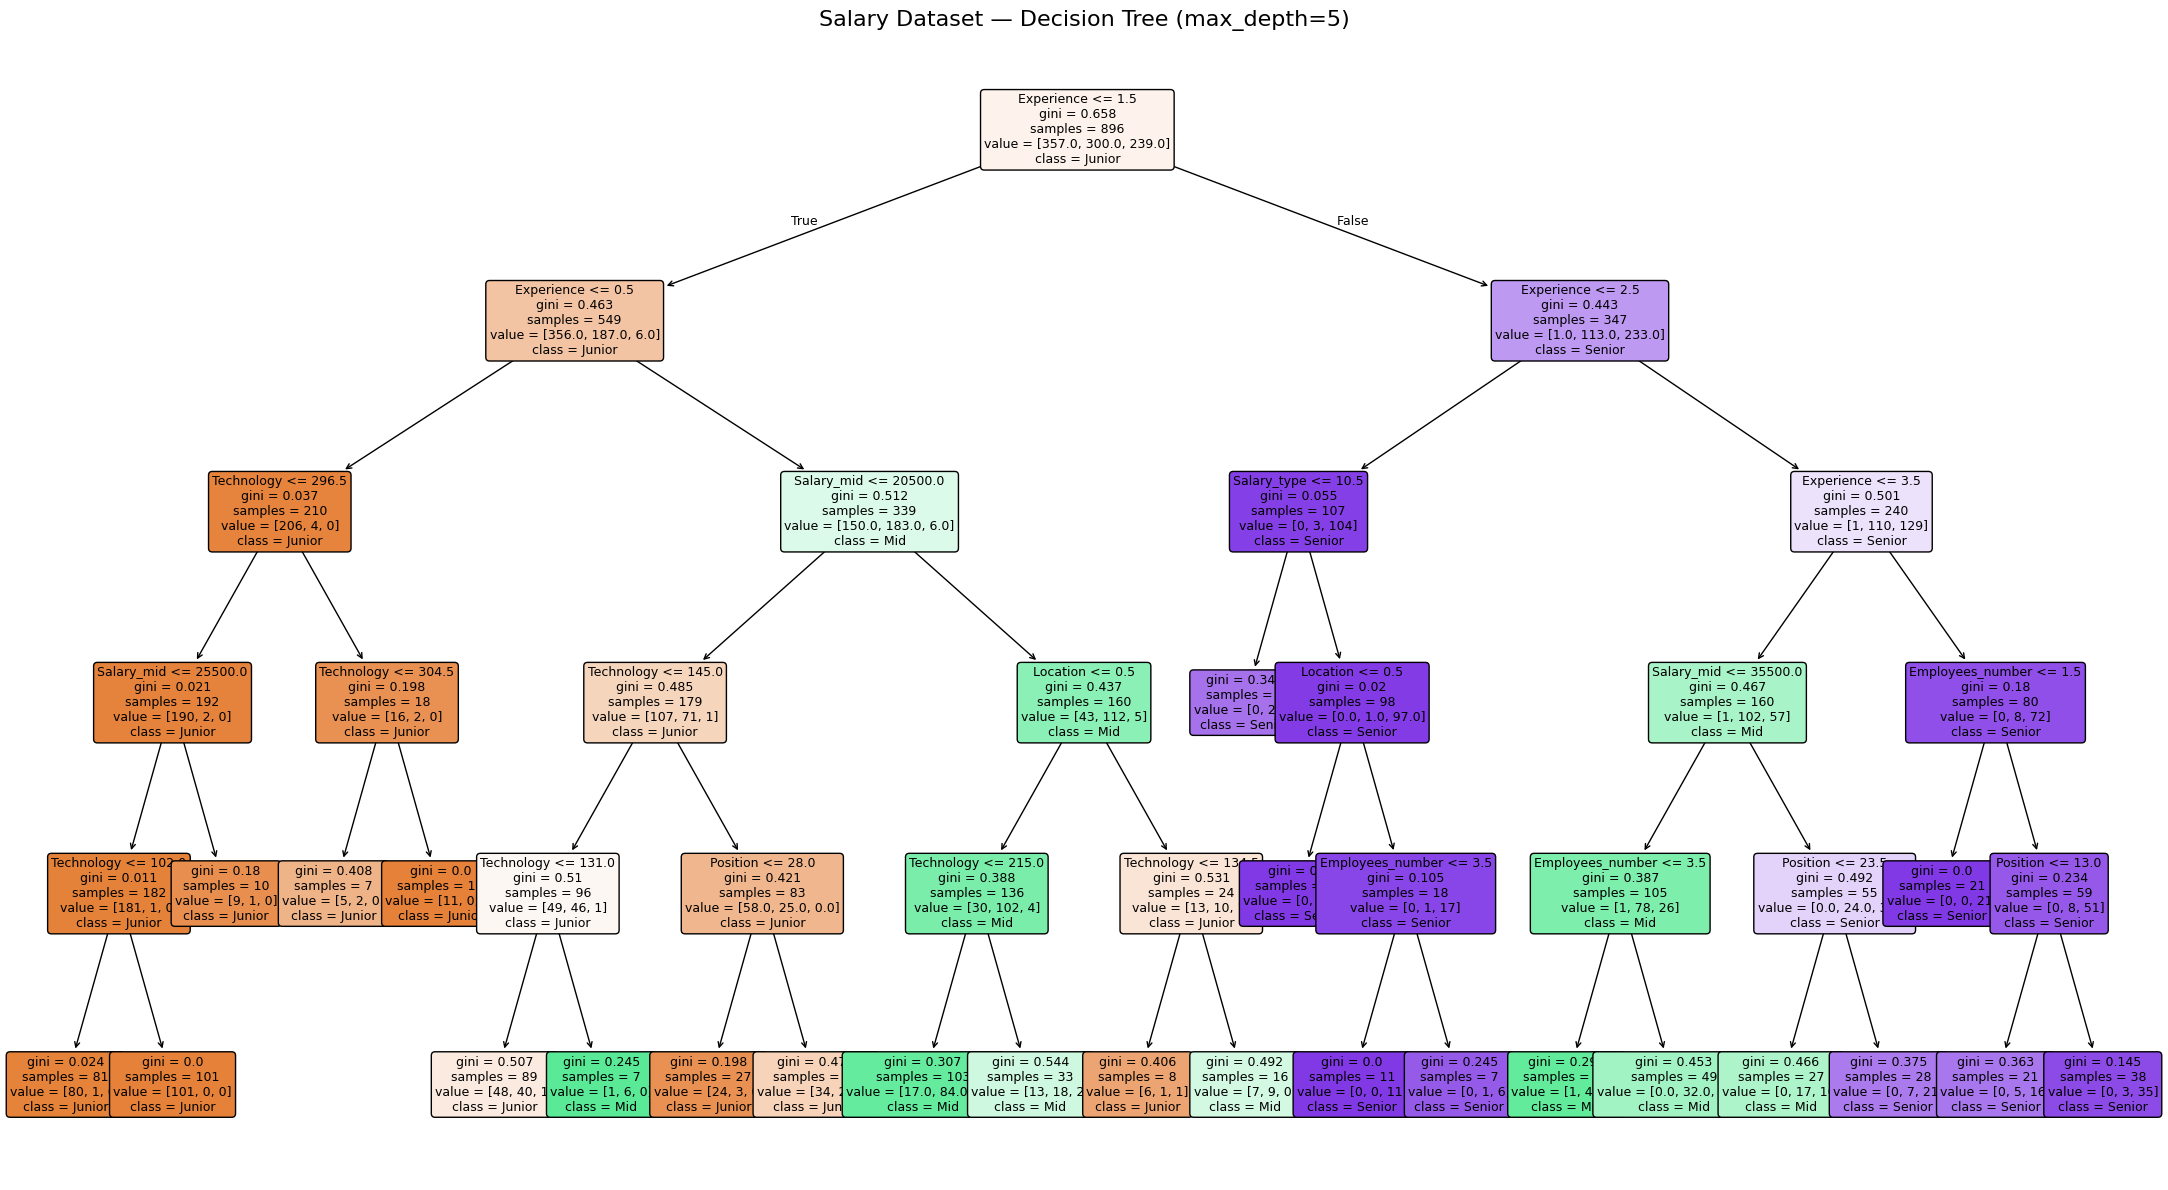

|--- Experience <= 1.50
|   |--- Experience <= 0.50
|   |   |--- Technology <= 296.50
|   |   |   |--- Salary_mid <= 25500.00
|   |   |   |   |--- Technology <= 102.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Technology >  102.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- Salary_mid >  25500.00
|   |   |   |   |--- class: 0
|   |   |--- Technology >  296.50
|   |   |   |--- Technology <= 304.50
|   |   |   |   |--- class: 0
|   |   |   |--- Technology >  304.50
|   |   |   |   |--- class: 0
|   |--- Experience >  0.50
|   |   |--- Salary_mid <= 20500.00
|   |   |   |--- Technology <= 145.00
|   |   |   |   |--- Technology <= 131.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Technology >  131.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- Technology >  145.00
|   |   |   |   |--- Position <= 28.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Position >  28.00
|   |   |   |   |   |--- class: 0
|   |   |--- Salary_mid >  20500.00
|   |   

In [ ]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

# GRAFİK GÖRSELLEŞTİRME
plt.figure(figsize=(22, 12))    # Geniş figür; 5 derinlikli ağaç sığması için

plot_tree(
    model,
    feature_names=list(X.columns),     # Düğümlerde sütun adlarını göster
    class_names=list(class_names),      # ['Junior','Mid','Senior']
    filled=True,                         # Düğümleri sınıf rengine göre doldur
    rounded=True,                        # Köşeleri yuvarla (estetik)
    fontsize=9,                          # Küçük font: bilgi sığsın
    impurity=True,                       # Gini değerini göster
    proportion=False                     # Örnek sayısını yüzde değil sayı göster
)

plt.title('Salary Dataset — Decision Tree (max_depth=5)', fontsize=16)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# METİNSEL AĞAÇ
tree_rules = export_text(
    model,
    feature_names=list(X.columns),
    spacing=3     # Her dal için 3 boşluk girintiyle yazdır
)
print(tree_rules)


# TEK ÖRNEK ÜZERİNDE TAHMİN + AÇIKLAMA
sample = X_test.iloc[[0]]  # Test setinden 1. örneği al
pred = model.predict(sample)
prob = model.predict_proba(sample)

print("\nÖrnek giriş:")
print(sample)
print(f"\nTahmin  : {le_target.inverse_transform(pred)[0]}")
print(f"Olasılık: Junior={prob[0][0]:.2f}, Mid={prob[0][1]:.2f}, Senior={prob[0][2]:.2f}")
print(f"Gerçek  : {le_target.inverse_transform(y_test.iloc[[0]])[0]}")

Veri Setinden Çıkarılan Sonuçlar
Maaş ve Deneyim belirleyicidir: Feature importance'a göre Salary_mid (%51) ve Experience (%20) birlikte Level'in %71'ini açıklıyor.
Lokasyon önemli (%6.8): Yurtdışı çalışanlar genel olarak daha yüksek Level'de — remote+döviz etkisi.
Teknoloji önemsiz (%0.7): C# vs Python vs Java fark etmez; Level seçimi teknoloji bağımsız.
Mid sınıfı belirsiz: Junior→Mid ve Mid→Senior geçiş noktaları keskin değil; bu gerçek hayatı yansıtıyor.
%82 doğruluk: 3 sınıflı dengesiz veri setinde makul. Ek özelliklerle (eğitim, sertifika vb.) artırılabilir.
